In [1]:
import requests

url = "https://services.nvd.nist.gov/rest/json/cves/2.0"

params = {
    "resultsPerPage": 5
}

response = requests.get(url, params=params)

print("Status Code:", response.status_code)

data = response.json()

for item in data["vulnerabilities"]:
    cve = item["cve"]
    cve_id = cve["id"]
    description = cve["descriptions"][0]["value"]

    print("\nCVE ID:", cve_id)
    print("Description:", description[:200])

Status Code: 200

CVE ID: CVE-1999-0095
Description: The debug command in Sendmail is enabled, allowing attackers to execute commands as root.

CVE ID: CVE-1999-0082
Description: CWD ~root command in ftpd allows root access.

CVE ID: CVE-1999-1471
Description: Buffer overflow in passwd in BSD based operating systems 4.3 and earlier allows local users to gain root privileges by specifying a long shell or GECOS field.

CVE ID: CVE-1999-1122
Description: Vulnerability in restore in SunOS 4.0.3 and earlier allows local users to gain privileges.

CVE ID: CVE-1999-1467
Description: Vulnerability in rcp on SunOS 4.0.x allows remote attackers from trusted hosts to execute arbitrary commands as root, possibly related to the configuration of the nobody user.


In [2]:
import json

with open("nvd_raw_data.json", "w") as file:
    json.dump(data, file, indent=4)

print("NVD data saved successfully!")

NVD data saved successfully!


In [3]:
import pandas as pd

records = []

for item in data["vulnerabilities"]:
    cve = item["cve"]

    records.append({
        "CVE_ID": cve["id"],
        "Description": cve["descriptions"][0]["value"],
        "Published": cve["published"],
        "Last_Modified": cve["lastModified"]
    })

df = pd.DataFrame(records)

df.to_csv("nvd_data.csv", index=False)

print(df)
print("\nCSV file saved successfully!")

          CVE_ID                                        Description  \
0  CVE-1999-0095  The debug command in Sendmail is enabled, allo...   
1  CVE-1999-0082      CWD ~root command in ftpd allows root access.   
2  CVE-1999-1471  Buffer overflow in passwd in BSD based operati...   
3  CVE-1999-1122  Vulnerability in restore in SunOS 4.0.3 and ea...   
4  CVE-1999-1467  Vulnerability in rcp on SunOS 4.0.x allows rem...   

                 Published            Last_Modified  
0  1988-10-01T04:00:00.000  2026-06-16T21:47:34.460  
1  1988-11-11T05:00:00.000  2026-06-16T21:47:32.300  
2  1989-01-01T05:00:00.000  2026-06-16T21:50:30.747  
3  1989-07-26T04:00:00.000  2026-06-16T21:49:46.027  
4  1989-10-26T04:00:00.000  2026-06-16T21:50:30.147  

CSV file saved successfully!


In [4]:
print("Number of records:", len(df))

print("\nDataset Information:")
df.info()

print("\nFirst 5 Records:")
display(df.head())

Number of records: 5

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CVE_ID         5 non-null      object
 1   Description    5 non-null      object
 2   Published      5 non-null      object
 3   Last_Modified  5 non-null      object
dtypes: object(4)
memory usage: 292.0+ bytes

First 5 Records:


,CVE_ID,Description,Published,Last_Modified
0,CVE-1999-0095,"The debug command in Sendmail is enabled, allo...",1988-10-01T04:00:00.000,2026-06-16T21:47:34.460
1,CVE-1999-0082,CWD ~root command in ftpd allows root access.,1988-11-11T05:00:00.000,2026-06-16T21:47:32.300
2,CVE-1999-1471,Buffer overflow in passwd in BSD based operati...,1989-01-01T05:00:00.000,2026-06-16T21:50:30.747
3,CVE-1999-1122,Vulnerability in restore in SunOS 4.0.3 and ea...,1989-07-26T04:00:00.000,2026-06-16T21:49:46.027
4,CVE-1999-1467,Vulnerability in rcp on SunOS 4.0.x allows rem...,1989-10-26T04:00:00.000,2026-06-16T21:50:30.147


In [5]:
import requests
from datetime import datetime, timedelta, timezone

url = "https://services.nvd.nist.gov/rest/json/cves/2.0"

end_date = datetime.now(timezone.utc)
start_date = end_date - timedelta(days=30)

params = {
    "pubStartDate": start_date.strftime("%Y-%m-%dT%H:%M:%S.000"),
    "pubEndDate": end_date.strftime("%Y-%m-%dT%H:%M:%S.000"),
    "resultsPerPage": 100
}

response = requests.get(url, params=params)

print("Status Code:", response.status_code)

data = response.json()

print("Total CVEs found:", data["totalResults"])

for item in data["vulnerabilities"][:5]:
    cve = item["cve"]
    print("\nCVE ID:", cve["id"])
    print("Published:", cve["published"])

Status Code: 200
Total CVEs found: 14047

CVE ID: CVE-2026-12710
Published: 2026-08-22T09:16:53.340

CVE ID: CVE-2026-78003
Published: 2026-08-22T09:16:53.543

CVE ID: CVE-2026-77945
Published: 2026-08-22T11:16:53.243

CVE ID: CVE-2026-77946
Published: 2026-08-22T11:16:54.447

CVE ID: CVE-2026-3424
Published: 2026-08-22T12:16:24.677


In [6]:
import pandas as pd

records = []

for item in data["vulnerabilities"]:
    cve = item["cve"]

    score = None
    severity = None

    metrics = cve.get("metrics", {})

    for version in ["cvssMetricV40", "cvssMetricV31", "cvssMetricV30"]:
        if version in metrics:
            cvss = metrics[version][0]["cvssData"]
            score = cvss.get("baseScore")
            severity = cvss.get("baseSeverity")
            break

    records.append({
        "CVE_ID": cve["id"],
        "Description": cve["descriptions"][0]["value"],
        "Published": cve["published"],
        "Last_Modified": cve["lastModified"],
        "CVSS_Score": score,
        "Severity": severity
    })

df = pd.DataFrame(records)

df.to_csv("nvd_recent_data.csv", index=False)

print(df.head())
print("\nRecent NVD data saved successfully!")

           CVE_ID                                        Description  \
0  CVE-2026-12710  A Missing Authorization vulnerability in the Q...   
1  CVE-2026-78003  The Mailgun for WordPress plugin for WordPress...   
2  CVE-2026-77945  A vulnerability was found in TRENDnet TEW-821D...   
3  CVE-2026-77946  A vulnerability was determined in TRENDnet TEW...   
4   CVE-2026-3424  The The kk Star Ratings – Rate Post & Collect ...   

                 Published            Last_Modified  CVSS_Score  Severity  
0  2026-08-22T09:16:53.340  2026-08-31T18:50:00.053         9.3  CRITICAL  
1  2026-08-22T09:16:53.543  2026-08-25T14:16:55.953         9.8  CRITICAL  
2  2026-08-22T11:16:53.243  2026-08-25T13:19:30.330         2.1       LOW  
3  2026-08-22T11:16:54.447  2026-08-26T18:17:03.530         9.3  CRITICAL  
4  2026-08-22T12:16:24.677  2026-08-26T18:16:31.763         5.3    MEDIUM  

Recent NVD data saved successfully!


In [7]:
print(df["Severity"].value_counts())

Severity
HIGH        40
MEDIUM      25
CRITICAL    21
LOW          3
Name: count, dtype: int64


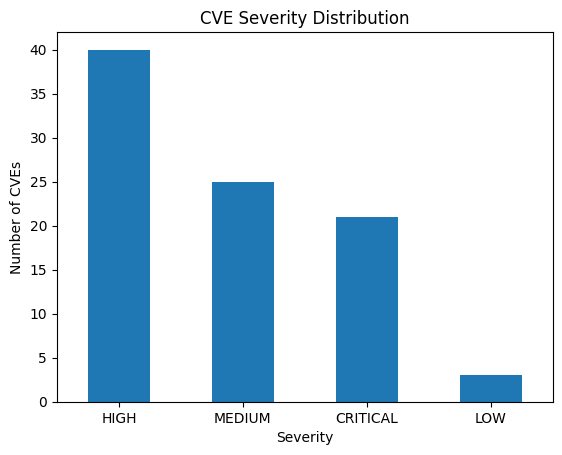

In [8]:
import matplotlib.pyplot as plt

df["Severity"].value_counts().plot(kind="bar")

plt.title("CVE Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of CVEs")
plt.xticks(rotation=0)
plt.show()

In [9]:
print(df.isnull().sum())

CVE_ID            0
Description       0
Published         0
Last_Modified     0
CVSS_Score       11
Severity         11
dtype: int64


In [10]:
df["Severity"] = df["Severity"].fillna("UNKNOWN")

print(df["Severity"].value_counts())

Severity
HIGH        40
MEDIUM      25
CRITICAL    21
UNKNOWN     11
LOW          3
Name: count, dtype: int64


In [11]:
df.to_csv("nvd_cleaned_data.csv", index=False)

print("Cleaned dataset")

Cleaned dataset
